In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import numpy as np

In [2]:
# import dataset as anndata object

dir = "/rds/general/user/ztb25/home/PBMC_datasets/4/PRJNA940789_GEX_matrix.h5ad" 

adata = sc.read_h5ad(dir)
adata.var_names_make_unique()

In [ ]:
adata

AnnData object with n_obs × n_vars = 467033 × 54977
    obs: 'sample', 'fastq_1', 'fastq_2'
    var: 'gene_symbols', 'feature_types', 'genome', 'gene_versions'

In [ ]:
# see if all of fastq_1 are just nan
adata.obs["fastq_2"].unique()

['nan']
Categories (1, object): ['nan']

In [5]:
#check how many unique samples
adata.obs["sample"].nunique()

50

In [6]:
adata.obs

,sample,fastq_1,fastq_2
TGCTACCTCACTCCTG-1_GSM7080062_cellbender_filter,GSM7080062_cellbender_filter,nan,nan
CGTAGCGAGTTAAGTG-1_GSM7080062_cellbender_filter,GSM7080062_cellbender_filter,nan,nan
CGAATGTCAGTATGCT-1_GSM7080062_cellbender_filter,GSM7080062_cellbender_filter,nan,nan
GCTGGGTCAATAGCAA-1_GSM7080062_cellbender_filter,GSM7080062_cellbender_filter,nan,nan
TCAGCTCAGAATGTTG-1_GSM7080062_cellbender_filter,GSM7080062_cellbender_filter,nan,nan
...,...,...,...
AACCGCGTCGTAGGAG-1_GSM7080013_cellbender_filter,GSM7080013_cellbender_filter,nan,nan
TGAGGGACAAGTTAAG-1_GSM7080013_cellbender_filter,GSM7080013_cellbender_filter,nan,nan
ACATGGTAGCCTCGTG-1_GSM7080013_cellbender_filter,GSM7080013_cellbender_filter,nan,nan
ACACCAACATGCAATC-1_GSM7080013_cellbender_filter,GSM7080013_cellbender_filter,nan,nan


In [7]:
display(adata.obs.head())
display(adata.var.head()) 

,sample,fastq_1,fastq_2
TGCTACCTCACTCCTG-1_GSM7080062_cellbender_filter,GSM7080062_cellbender_filter,nan,nan
CGTAGCGAGTTAAGTG-1_GSM7080062_cellbender_filter,GSM7080062_cellbender_filter,nan,nan
CGAATGTCAGTATGCT-1_GSM7080062_cellbender_filter,GSM7080062_cellbender_filter,nan,nan
GCTGGGTCAATAGCAA-1_GSM7080062_cellbender_filter,GSM7080062_cellbender_filter,nan,nan
TCAGCTCAGAATGTTG-1_GSM7080062_cellbender_filter,GSM7080062_cellbender_filter,nan,nan


,gene_symbols,feature_types,genome,gene_versions
ENSG00000142611,PRDM16,Gene Expression,cellranger_reference,ENSG00000142611
ENSG00000284616,ENSG00000284616,Gene Expression,cellranger_reference,ENSG00000284616
ENSG00000260972,ENSG00000260972,Gene Expression,cellranger_reference,ENSG00000260972
ENSG00000232596,LINC01646,Gene Expression,cellranger_reference,ENSG00000232596
ENSG00000231510,LINC02782,Gene Expression,cellranger_reference,ENSG00000231510


In [8]:
pd.DataFrame(
    adata.X[:10, :20].toarray(),
    index=adata.obs_names[:10],
    columns=adata.var_names[:20]
)

,ENSG00000142611,ENSG00000284616,ENSG00000260972,ENSG00000232596,ENSG00000231510,ENSG00000149527,ENSG00000272235,ENSG00000284694,ENSG00000224387,ENSG00000284674,ENSG00000287727,ENSG00000142606,ENSG00000229393,ENSG00000287586,ENSG00000227169,ENSG00000225387,ENSG00000048707,ENSG00000285833,ENSG00000285945,ENSG00000197921
TGCTACCTCACTCCTG-1_GSM7080062_cellbender_filter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
CGTAGCGAGTTAAGTG-1_GSM7080062_cellbender_filter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CGAATGTCAGTATGCT-1_GSM7080062_cellbender_filter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GCTGGGTCAATAGCAA-1_GSM7080062_cellbender_filter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TCAGCTCAGAATGTTG-1_GSM7080062_cellbender_filter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
CATCAGATCCGCGCAA-1_GSM7080062_cellbender_filter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TAGTGGTTCCCACTTG-1_GSM7080062_cellbender_filter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CACCTTGAGACTGGGT-1_GSM7080062_cellbender_filter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
GACCAATTCTTGACGA-1_GSM7080062_cellbender_filter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
ATCCACCTCTGGTATG-1_GSM7080062_cellbender_filter,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# extract GSM id from sample name

adata.obs["gsm_id"] = adata.obs["sample"].str.split("_").str[0]

adata.obs["gsm_id"].unique()

array(['GSM7080062', 'GSM7080061', 'GSM7080060', 'GSM7080059',
       'GSM7080058', 'GSM7080057', 'GSM7080056', 'GSM7080055',
       'GSM7080054', 'GSM7080053', 'GSM7080052', 'GSM7080051',
       'GSM7080050', 'GSM7080049', 'GSM7080048', 'GSM7080047',
       'GSM7080046', 'GSM7080045', 'GSM7080044', 'GSM7080043',
       'GSM7080042', 'GSM7080041', 'GSM7080040', 'GSM7080039',
       'GSM7080038', 'GSM7080037', 'GSM7080036', 'GSM7080035',
       'GSM7080034', 'GSM7080033', 'GSM7080032', 'GSM7080031',
       'GSM7080030', 'GSM7080029', 'GSM7080028', 'GSM7080027',
       'GSM7080026', 'GSM7080025', 'GSM7080024', 'GSM7080023',
       'GSM7080022', 'GSM7080021', 'GSM7080020', 'GSM7080019',
       'GSM7080018', 'GSM7080017', 'GSM7080016', 'GSM7080015',
       'GSM7080014', 'GSM7080013'], dtype=object)

In [10]:
# Change sample column to 1-50, change type, and make sure is in numeric order

sample_order = [str(i) for i in range(1, 51)]   # ["1", "2", ..., "50"]

adata.obs["sample"] = pd.Categorical(
    (adata.obs["gsm_id"].astype("category").cat.codes + 1).astype(str),
    categories=sample_order,
    ordered=False,
)

In [11]:
# Add missing metadata

sample_meta = pd.DataFrame({
    "sample_num": ["1028", "1241", "906", "1034", "1055", "1092","1120","1160","254","1052","516","696","1273","738","911","1180","773","863","1279","598","917","932","780","802","1020","942","968","1147","781","1111","656","912","978","1282","953","820","1162","989","1010","965","921","230","836","1236","1237","1200","947","70","970","905"],
    "gsm_id": ["GSM7080013","GSM7080014","GSM7080015","GSM7080016","GSM7080017","GSM7080018", "GSM7080019","GSM7080020","GSM7080021","GSM7080022","GSM7080023","GSM7080024","GSM7080025","GSM7080026","GSM7080027","GSM7080028","GSM7080029","GSM7080030","GSM7080031","GSM7080032","GSM7080033","GSM7080034","GSM7080035","GSM7080036","GSM7080037","GSM7080038","GSM7080039","GSM7080040","GSM7080041","GSM7080042","GSM7080043","GSM7080044","GSM7080045","GSM7080046","GSM7080047","GSM7080048","GSM7080049", "GSM7080050","GSM7080051","GSM7080052","GSM7080053","GSM7080054","GSM7080055","GSM7080056","GSM7080057","GSM7080058", "GSM7080059","GSM7080060", "GSM7080061", "GSM7080062"],
    "diagnosis": ["CTRL", "AD", "AD", "AD", "AD", "AD", "AD", "AD", "AD", "AD", "AD", "AD", "CTRL", "AD", "CTRL", "CTRL", "AD", "AD", "CTRL", "CTRL", "AD", "AD", "CTRL", "AD", "CTRL", "AD", "CTRL", "AD", "CTRL", "CTRL", "AD", "CTRL", "CTRL", "CTRL", "AD", "CTRL", "CTRL", "CTRL", "CTRL", "AD", "AD", "AD", "CTRL", "AD", "AD", "CTRL", "AD", "AD", "CTRL", "CTRL"],
}).set_index("gsm_id")

adata.obs = adata.obs.join(sample_meta, on="gsm_id", how="left")
adata.obs.head()

,sample,fastq_1,fastq_2,gsm_id,sample_num,diagnosis
TGCTACCTCACTCCTG-1_GSM7080062_cellbender_filter,50,nan,nan,GSM7080062,905,CTRL
CGTAGCGAGTTAAGTG-1_GSM7080062_cellbender_filter,50,nan,nan,GSM7080062,905,CTRL
CGAATGTCAGTATGCT-1_GSM7080062_cellbender_filter,50,nan,nan,GSM7080062,905,CTRL
GCTGGGTCAATAGCAA-1_GSM7080062_cellbender_filter,50,nan,nan,GSM7080062,905,CTRL
TCAGCTCAGAATGTTG-1_GSM7080062_cellbender_filter,50,nan,nan,GSM7080062,905,CTRL


In [12]:
# Add in age and gender metadata from csv file
meta_df = pd.read_csv("/rds/general/user/ztb25/home/PBMC_datasets/4/SraRunTable.csv")

# subset to desired metadata
meta_df = meta_df[["AGE", "sex", "Library Name"]].rename(columns={"AGE" : "age", "sex" : "gender", "Library Name" : "gsm_id"})

# Drop duplicate gsm_ids before merging
meta_df = meta_df.drop_duplicates(subset="gsm_id")

# merge by gsm_id using pd.concat
adata.obs = adata.obs.reset_index().merge(meta_df, on="gsm_id", how="left").set_index("index")

adata.obs.head()

,sample,fastq_1,fastq_2,gsm_id,sample_num,diagnosis,age,gender
index,,,,,,,,
TGCTACCTCACTCCTG-1_GSM7080062_cellbender_filter,50,nan,nan,GSM7080062,905,CTRL,87,male
CGTAGCGAGTTAAGTG-1_GSM7080062_cellbender_filter,50,nan,nan,GSM7080062,905,CTRL,87,male
CGAATGTCAGTATGCT-1_GSM7080062_cellbender_filter,50,nan,nan,GSM7080062,905,CTRL,87,male
GCTGGGTCAATAGCAA-1_GSM7080062_cellbender_filter,50,nan,nan,GSM7080062,905,CTRL,87,male
TCAGCTCAGAATGTTG-1_GSM7080062_cellbender_filter,50,nan,nan,GSM7080062,905,CTRL,87,male


In [13]:
# sanity check that every sample got age and gender

missing_age = adata.obs["age"].isna().sum()
missing_gender = adata.obs["gender"].isna().sum()
assert missing_age == 0 and missing_gender == 0, \
    f"{missing_age} cells missing age, {missing_gender} missing gender"

In [14]:
# calculate proportions of samples in age bands (50-59, 60-69, 70-79, 80+), for age-matching with control dataset

# extract from obs, one row per sample with age and diagnosis
sample_ages = adata.obs[["sample", "age", "diagnosis"]].drop_duplicates(subset="sample").copy()
sample_ages["age"] = pd.to_numeric(sample_ages["age"], errors="coerce")

# define age bands (include a 45-50 bin for this dataset)
bins = [39, 49, 59, 69, 79, 200]
labels = ["40-50", "50-59", "60-69", "70-79", "80+"]

sample_ages["age_band"] = pd.cut(sample_ages["age"], bins=bins, labels=labels, right=True, include_lowest=True)

# overall counts and proportions of samples per age band
age_band_counts = sample_ages["age_band"].value_counts().reindex(labels, fill_value=0)
age_band_props = (age_band_counts / age_band_counts.sum()).round(3)
age_band_counts = pd.DataFrame({"count": age_band_counts, "proportion": age_band_props})

display(age_band_counts)

# proportions by diagnosis (only interested in AD)
by_diag_counts = sample_ages.groupby(["diagnosis", "age_band"]).size().unstack(fill_value=0).reindex(columns=labels, fill_value=0)
by_diag_prop = by_diag_counts.div(by_diag_counts.sum(axis=1), axis=0).round(3)

display(by_diag_counts)
display(by_diag_prop)

# save proprtions per age band by diagnosis
out_path = "/rds/general/user/ztb25/home/PBMC_datasets/4/age_band_props_by_diagnosis.csv"
by_diag_counts.to_csv(out_path)

,count,proportion
40-50,1,0.02
50-59,3,0.06
60-69,15,0.30
70-79,18,0.36
80+,13,0.26


age_band,40-50,50-59,60-69,70-79,80+
diagnosis,,,,,
AD,1,2,8,9,8
CTRL,0,1,7,9,5


age_band,40-50,50-59,60-69,70-79,80+
diagnosis,,,,,
AD,0.036,0.071,0.286,0.321,0.286
CTRL,0.000,0.045,0.318,0.409,0.227


In [15]:
# calculate gender counts, overall and by diagnosis

gender_counts = adata.obs.drop_duplicates("sample")["gender"].value_counts()
gender_by_diag_counts = adata.obs.drop_duplicates("sample").groupby("diagnosis")["gender"].value_counts().unstack(fill_value=0)

display(gender_counts)
display(gender_by_diag_counts)


male      26
female    24
Name: gender, dtype: int64

gender,female,male
diagnosis,,
AD,14,14
CTRL,10,12


In [16]:
# Run QC globally

# Annotate mitochondrial genes (from gene_symbols col)
adata.var["mt"] = adata.var["gene_symbols"].str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"], 
    percent_top=[20],
    log1p=True,
    inplace=True
)

adata # to check new metadata cols

AnnData object with n_obs × n_vars = 467033 × 54977
    obs: 'sample', 'fastq_1', 'fastq_2', 'gsm_id', 'sample_num', 'diagnosis', 'age', 'gender', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_symbols', 'feature_types', 'genome', 'gene_versions', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

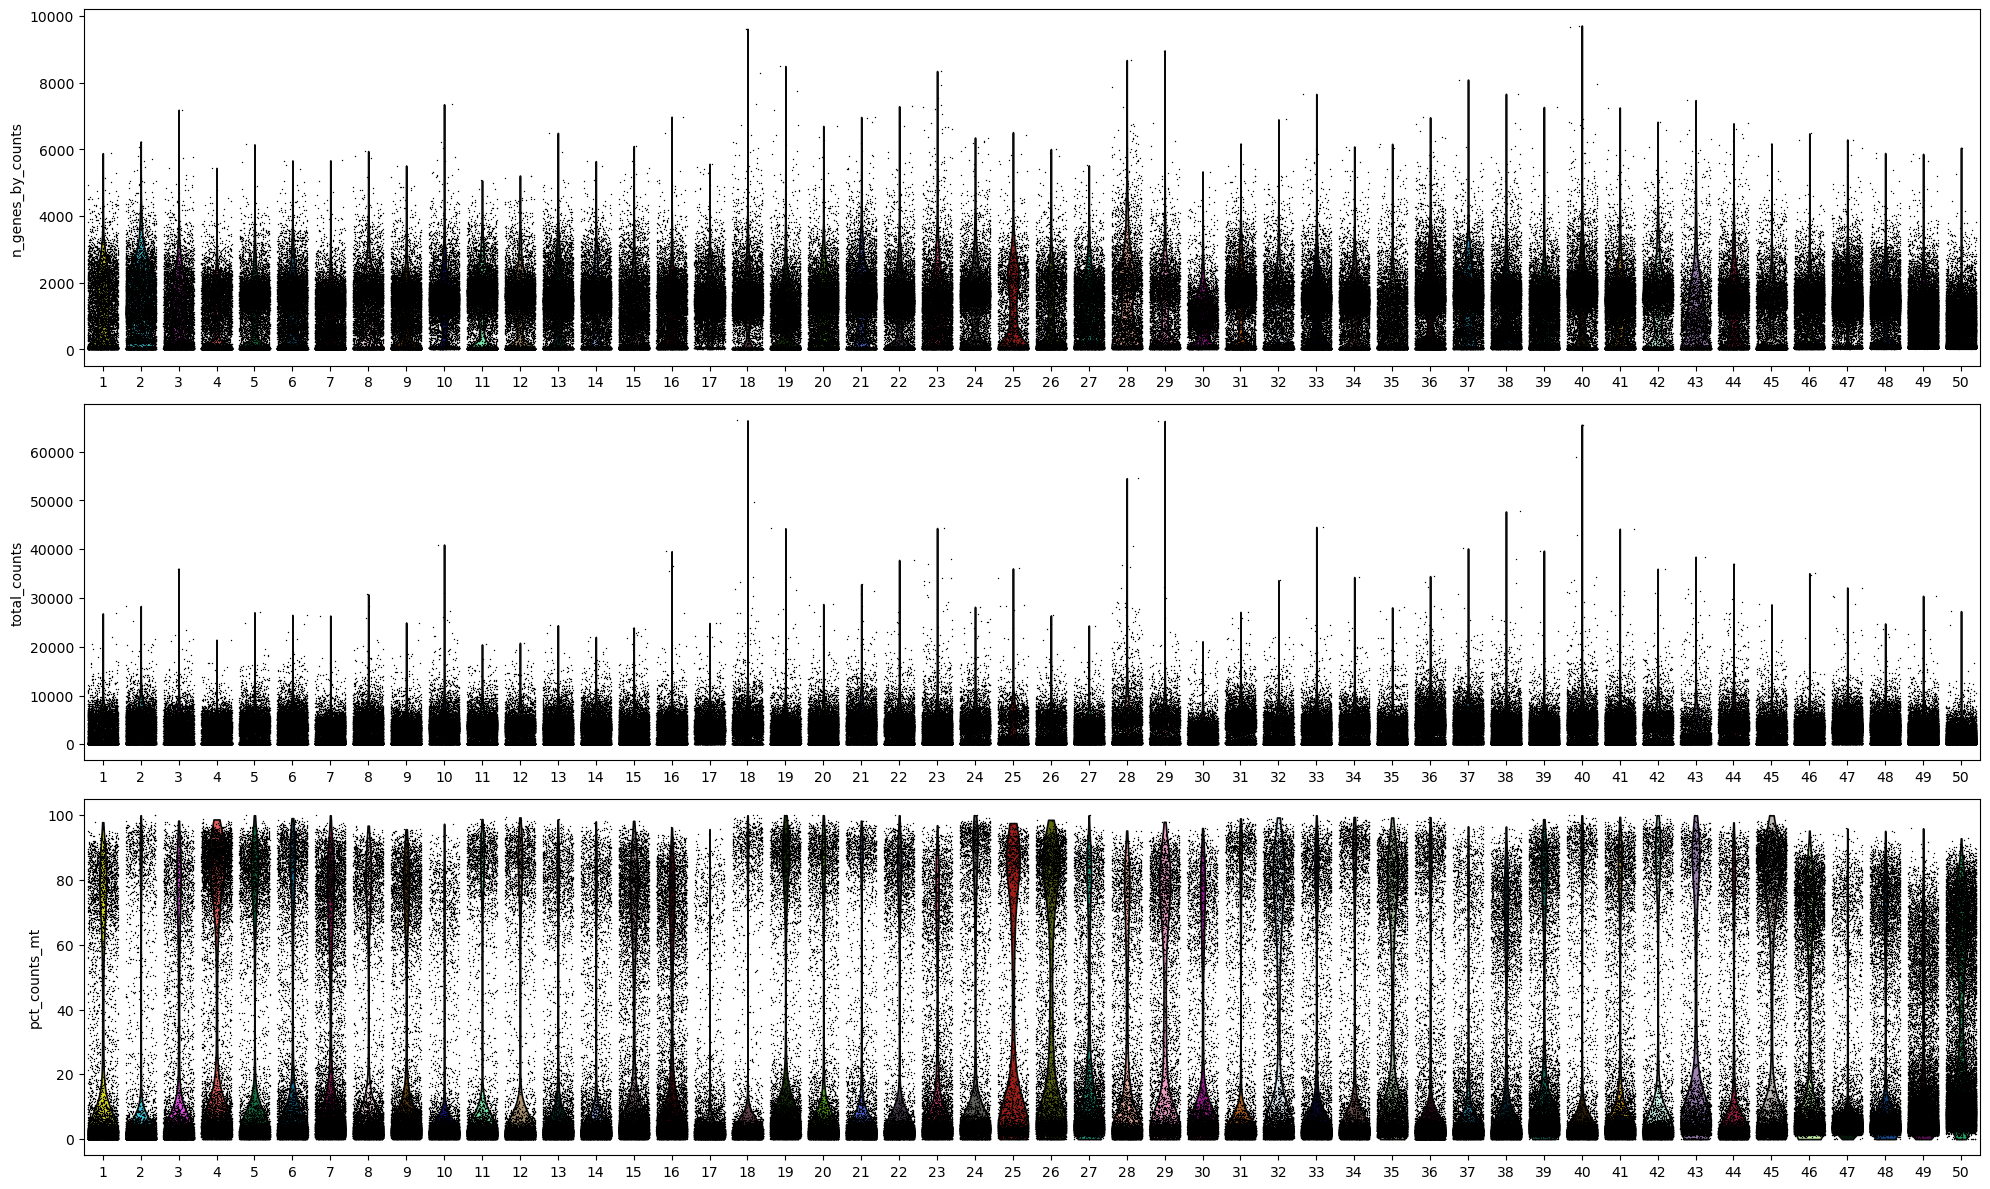

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(20, 12))

for ax, metric in zip(axes, ["n_genes_by_counts", "total_counts", "pct_counts_mt"]):
    sc.pl.violin(adata, metric, groupby="sample", jitter=0.4, ax=ax, show=False)
    ax.set_xlabel("")  

plt.tight_layout()
plt.show()

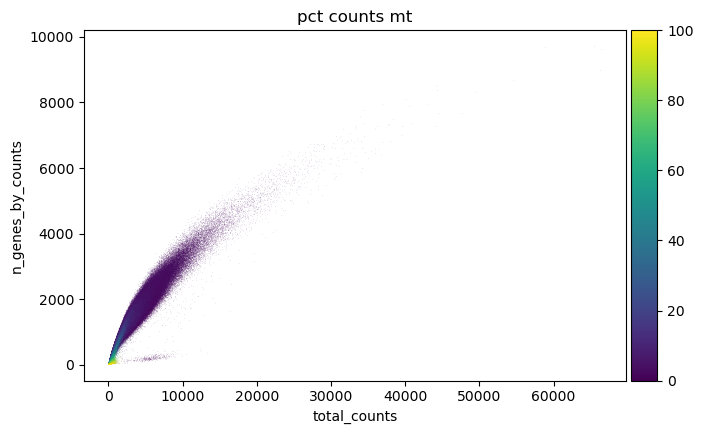

In [18]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [ ]:
# group by sample (to avoid skewing from bad samples) and flag outliers based on median absolute deviation (MAD).

def is_outlier_per_sample(adata, metric: str, nmads: int):
    outlier = pd.Series(False, index=adata.obs_names)
    
    for sample, group in adata.obs.groupby("sample"):
        M = group[metric]
        is_out = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
            np.median(M) + nmads * median_abs_deviation(M) < M
        )
        outlier[is_out.index] = is_out
    
    return outlier

In [20]:
adata.obs["outlier"] = (
    is_outlier_per_sample(adata, "log1p_total_counts", 5) # log values easier to visalise and compare (raw total_counts can vary hugely across cells)
    | is_outlier_per_sample(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier_per_sample(adata, "pct_counts_in_top_20_genes", 5) # gives what percentage of total counts comes from the top 20 most highly expressed genes, cells with very high values here are likely to be low quality cells where a few genes dominate the expression profile, which can be a sign of cell stress or damage
)
adata.obs.outlier.value_counts()

False    375159
True      91874
Name: outlier, dtype: int64

In [21]:
adata.obs["mt_outlier"] = is_outlier_per_sample(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

False    302646
True     164387
Name: mt_outlier, dtype: int64

In [22]:
# filter out low quality cells, check how many cells before and after filtering, and save per sample for later dataframe
cells_before = adata.n_obs
cells_per_sample_before = adata.obs.groupby('sample').size().rename("cells_before_qc")
n_samples = adata.obs["sample"].nunique()

print(f"Total number of cells before filtering of low quality cells: {cells_before}")
# print(f"Number of cells per sample before filtering:\n{cells_per_sample_before}")

adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()
cells_per_sample_after_filtering = adata.obs.groupby("sample").size().rename("cells_after_lowq_qc")

print(f"Total number of cells after filtering of low quality cells: {adata.n_obs}")
# print(f"Number of cells per sample after filtering:\n{cells_per_sample_after_filtering}") #intermediate measure just to see (maybe remove), final dataframe will only have final before/after numbers

Total number of cells before filtering of low quality cells: 467033
Total number of cells after filtering of low quality cells: 299391


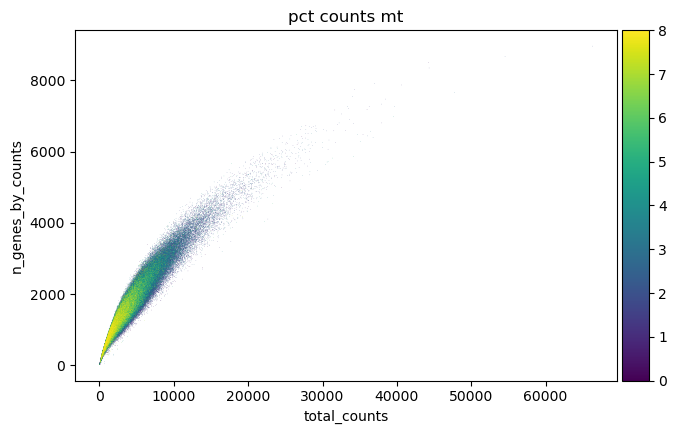

In [23]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [24]:
# Filter out genes not detected in at least 20 cells (not informative)

print(f"Total number of genes: {adata.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=20)
print(f"Number of genes after cell filter: {adata.n_vars}")

Total number of genes: 54977
Number of genes after cell filter: 33234


In [25]:
# doublet detection

sc.pp.scrublet(adata, batch_key="sample")

In [26]:
# inspect new metadata cols and number of predicted doublets 
display(adata.obs[['doublet_score','predicted_doublet']])
adata.obs['predicted_doublet'].value_counts()

,doublet_score,predicted_doublet
index,,
TGCTACCTCACTCCTG-1_GSM7080062_cellbender_filter,0.216495,True
CGTAGCGAGTTAAGTG-1_GSM7080062_cellbender_filter,0.026750,False
CGAATGTCAGTATGCT-1_GSM7080062_cellbender_filter,0.081703,False
GCTGGGTCAATAGCAA-1_GSM7080062_cellbender_filter,0.091824,False
TCAGCTCAGAATGTTG-1_GSM7080062_cellbender_filter,0.069388,False
...,...,...
TAAACCGGTAGCGTCC-1_GSM7080013_cellbender_filter,0.016284,False
GTTACAGTCCGTCATC-1_GSM7080013_cellbender_filter,0.014366,False
AGCAGCCCACCCTATC-1_GSM7080013_cellbender_filter,0.024198,False


False    295440
True       3951
Name: predicted_doublet, dtype: int64

In [27]:
# sc.pp.scrublet_simulate_doublets(adata)
# sc.pl.scrublet_score_distribution(adata)

## too mant samples, dont need to run every time (just checked the first time)

In [28]:
# per sample predicted doublets
doublets_predicted = (adata.obs.groupby("sample")["predicted_doublet"].sum().astype(int).rename("doublets_predicted"))

In [29]:
# Filter out doublets

adata = adata[~adata.obs['predicted_doublet']].copy()

In [30]:
adata.obs.dtypes

sample                          object
fastq_1                       category
fastq_2                       category
gsm_id                          object
sample_num                      object
diagnosis                       object
age                              int64
gender                          object
n_genes_by_counts                int32
log1p_n_genes_by_counts        float64
total_counts                   float32
log1p_total_counts             float32
pct_counts_in_top_20_genes     float64
total_counts_mt                float32
log1p_total_counts_mt          float32
pct_counts_mt                  float32
outlier                           bool
mt_outlier                        bool
n_genes                          int64
doublet_score                  float64
predicted_doublet                 bool
dtype: object

In [31]:
# Save dataset at this stage (after QC but before log transformation, HVG selection))

ad.settings.allow_write_nullable_strings = True
adata.write("/rds/general/user/ztb25/home/PBMC_datasets/4/QC_rawcounts.h5ad")

In [32]:
adata.obs["sample"] = adata.obs["sample"].astype(str).astype("category")


In [33]:
# create and export summary table of number of samples/cells per sample before and after filtering

cells_per_sample_after = adata.obs.groupby("sample").size().rename("cells_after_qc")
total_cells_after = adata.n_obs

summary_table = pd.concat(
    [
    cells_per_sample_before, 
    # doublets_predicted,
    cells_per_sample_after
    ],
    axis=1
).astype(int)

# derive removal columns
summary_table["removed_cells"] = (summary_table["cells_before_qc"] - summary_table["cells_after_qc"])
summary_table["pct_removed"] = (
    100 * summary_table["removed_cells"] / summary_table["cells_before_qc"]
).round(2)

summary_table = summary_table.reset_index()  # makes "sample" a normal column

# add diagnosis 
diag_map = adata.obs[["sample", "diagnosis"]].drop_duplicates()
summary_table = summary_table.merge(diag_map, on="sample", how="left")

total_row = pd.DataFrame([{
    "sample": "TOTAL",
    "cells_before_qc": summary_table["cells_before_qc"].sum(),
    # "doublets_predicted": summary_table["doublets_predicted"].sum(),
    "cells_after_qc": summary_table["cells_after_qc"].sum(),
    "removed_cells": summary_table["removed_cells"].sum(),
    "pct_removed": round(
        100 * summary_table["removed_cells"].sum() / summary_table["cells_before_qc"].sum(), 2
    )
}])

summary_table = pd.concat([summary_table, total_row], axis=0, ignore_index=True)

#reorder columns
summary_table = summary_table[
    ["sample", "diagnosis", "cells_before_qc", "cells_after_qc", "removed_cells", "pct_removed"]
]

summary_table.to_csv("/rds/general/user/ztb25/home/PBMC_datasets/4/QC_summary_table.csv", index=False)

In [34]:
summary_table

,sample,diagnosis,cells_before_qc,cells_after_qc,removed_cells,pct_removed
0,1,CTRL,6833,4228,2605,38.12
1,2,AD,7939,6502,1437,18.10
2,3,AD,7561,5203,2358,31.19
3,4,AD,10295,4716,5579,54.19
4,5,AD,9604,6291,3313,34.50
5,6,AD,10090,6275,3815,37.81
6,7,AD,11746,6166,5580,47.51
7,8,AD,8079,5162,2917,36.11
8,9,AD,9670,6005,3665,37.90
9,10,AD,8662,6530,2132,24.61


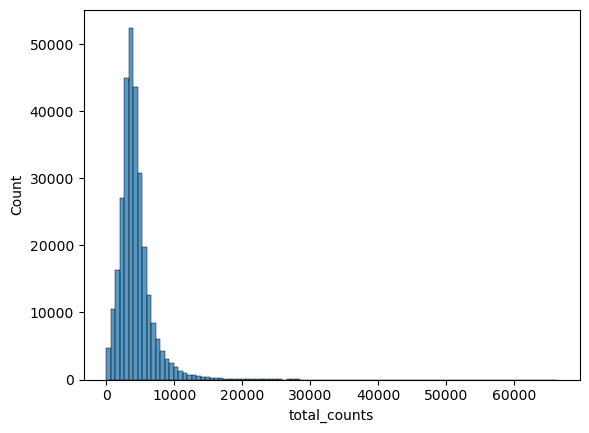

In [35]:
##### Normalisation ##### ----------------------------------------------------------------------------------------------------

# inspect distribution of the raw counts
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

In [36]:
# normalise counts to sum to the median pre-normalisation
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False) #changes not made to adata.X

# log1p transform (shifted logarithm, from sc-best practice) and add to layer
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True) 

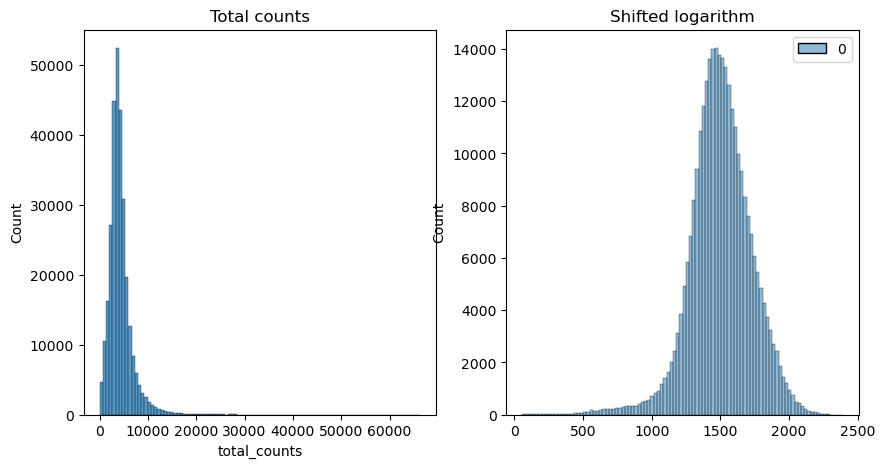

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [38]:
# check total counts per cell again
X_norm = scales_counts["X"]

norm_totals = np.array(X_norm.sum(axis=1)).flatten()
print(pd.Series(norm_totals).describe())

count    295440.000000
mean       3882.999756
std           0.000238
min        3882.999023
25%        3882.999756
50%        3883.000000
75%        3883.000244
max        3883.001221
dtype: float64


In [39]:
adata

AnnData object with n_obs × n_vars = 295440 × 33234
    obs: 'sample', 'fastq_1', 'fastq_2', 'gsm_id', 'sample_num', 'diagnosis', 'age', 'gender', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'gene_symbols', 'feature_types', 'genome', 'gene_versions', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'sample_colors', 'scrublet'
    layers: 'log1p_norm'

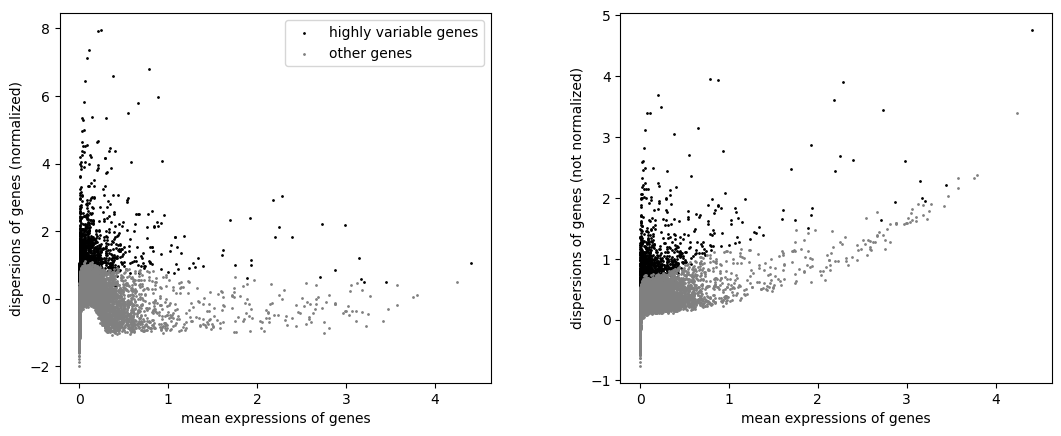

In [40]:
##### Feature Selection ##### ----------------------------------------------------------------------------------------------------
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample", layer = "log1p_norm") # automatically adds columns to adata.var 'highly_variable', 'means', 'dispersions', 'dispersions_norm'. Downstream functions like pca will automatically use only the HVGs if use_highly_variable=True is passed.
sc.pl.highly_variable_genes(adata)

# Mean expression is simply the average expression level of a gene across all cells — how highly expressed it is on average.
# Dispersion is a measure of how much a gene's expression varies across cells, normalized for its mean.

In [41]:
# Save final dataset for integration

adata.write("/rds/general/user/ztb25/home/PBMC_datasets/4/PBMC4_preprocessed.h5ad")